# Multiprocess a folder and summarize the flux timeseries (MCMC)

Point `data_folder` at a single day's folder of JSON chamber files. The cell below loads the raw data, runs the `Multiprocessor` in MCMC mode across CPU cores, selects the Pareto-optimal (deadband, cutoff) per measurement, and plots the resulting `dcdt(HM)` timeseries with a 16–84 percentile band.

In [22]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import logging
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from soilgasflux_fcs import Multiprocessor, json_reader

logging.getLogger('soilgasflux_fcs').setLevel(logging.INFO)

In [24]:
data_folder = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Gals/2026_tpclass/low-cost sensor/2-2/data/2026-03-19')
output_folder = pathlib.Path('/Users/alexnaokiasatokobayashi/Downloads/test_output')
output_folder.mkdir(parents=True, exist_ok=True)
chamber_id = data_folder.parent.parent.name

In [25]:
initializer = json_reader.Initializer(folderPath=data_folder)
df = initializer.prepare_rawdata()
print(f'{df["id"].nunique()} measurements, {len(df)} rows')
df.head()

21 measurements, 2520 rows


,datetime_utc,si_temperature,bmp_temperature,si_humidity,datetime,k30_co2,bmp_pressure,id,timedelta
0,2026-03-19 11:41:09,27.496376,29.17,31.185668,2026-03-19 11:41:09,415,97105.28,2026-03-19_11-41-09,0
1,2026-03-19 11:41:10,27.485656,29.23,31.734986,2026-03-19 11:41:10,416,97105.17,2026-03-19_11-41-09,1
2,2026-03-19 11:41:12,27.496376,29.28,32.360596,2026-03-19 11:41:12,416,97105.31,2026-03-19_11-41-09,3
3,2026-03-19 11:41:13,27.474930,29.33,32.955690,2026-03-19 11:41:13,417,97106.17,2026-03-19_11-41-09,4
4,2026-03-19 11:41:14,27.485656,29.39,33.581300,2026-03-19 11:41:14,417,97106.32,2026-03-19_11-41-09,5


`run_MC` runs emcee per (deadband, cutoff) window, then `select_bestPareto` picks the Pareto-optimal window per timestamp and writes `<chamber_id>_<date>_bestPareto.nc` into `output_folder`.

In [26]:
processor = Multiprocessor()
ds_mc = processor.run_MC(df=df, 
                         chamber_id=chamber_id, 
                         output_folder=str(output_folder), 
                         sensor_precision=10)
ds_mc

INFO soilgasflux_fcs.multiprocess_raw_data: Multiprocessing (MC) started on 14 CPUs
INFO soilgasflux_fcs.multiprocess_raw_data: Processing date 2026-03-19


emcee: Exception while calling your likelihood function:
  params: [6.46065301e-04 6.89678140e+01 3.78355051e+01]
  args: (array([  0,   1,   2,   3,   4,   5,   6,   8,   9,  10,  11,  12,  13,
        14,  16,  17,  18,  19,  20,  21,  22,  24,  25,  26,  27,  29,
        30,  32,  33,  34,  36,  37,  38,  39,  40,  41,  43,  44,  45,
        46,  47,  48,  49,  51,  52,  53,  54,  55,  56,  57,  59,  60,
        61,  62,  63,  64,  65,  67,  68,  69,  70,  71,  72,  74,  75,
        76,  77,  78,  79,  80,  82,  83,  84,  85,  86,  87,  88,  90,
        91,  92,  93,  94,  95,  96,  98,  99, 100, 101, 102, 103, 105,
       106, 108, 109, 110, 112, 113, 115, 116, 117, 119, 120, 122, 123,
       124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 135, 137, 138,
       139, 140, 141]), array([445, 445, 445, 446, 446, 447, 447, 449, 449, 450, 452, 452, 454,
       454, 456, 456, 460, 463, 463, 467, 467, 470, 470, 478, 487, 495,
       495, 502, 510, 510, 517, 525, 525, 532, 532, 546, 546,

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (120,) (130,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=130: operands could not be broadcast together with shapes (120,) (130,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return s

emcee: Exception while calling your likelihood function:
  params: [1.09497448e-04 7.25957384e+04 2.80523889e+01]
  args: (array([  0,   1,   2,   3,   5,   6,   7,   8,   9,  10,  12,  13,  15,
        16,  17,  19,  20,  21,  22,  23,  25,  26,  27,  28,  29,  30,
        31,  33,  34,  35,  36,  37,  38,  39,  41,  42,  43,  44,  45,
        46,  47,  49,  50,  51,  52,  53,  54,  55,  57,  58,  59,  60,
        61,  62,  63,  65,  66,  67,  68,  69,  70,  71,  73,  74,  75,
        76,  77,  78,  80,  81,  82,  83,  84,  85,  86,  88,  89,  90,
        91,  92,  93,  94,  96,  97,  98,  99, 100, 101, 102, 104, 105,
       106, 107, 108, 110, 111, 113, 114, 116, 117, 118, 120, 121, 122,
       123, 125, 126, 127, 128, 129, 130, 131, 133, 134, 135, 136, 137,
       138, 139, 141]), array([458, 458, 463, 463, 468, 472, 472, 477, 477, 484, 493, 493, 501,
       508, 514, 514, 522, 522, 527, 527, 534, 541, 541, 547, 547, 554,
       554, 560, 560, 566, 571, 571, 572, 572, 580, 580, 587,

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (120,) (130,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=0 cutoff=130: operands could not be broadcast together with shapes (120,) (130,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return s

...

emcee: Exception while calling your likelihood function:
  params: [3.17025133e-04 4.71674601e+04 4.14117536e+01]
  args: (array([ 59,  60,  61,  62,  63,  64,  66,  67,  68,  69,  70,  71,  73,
        74,  75,  76,  77,  78,  79,  81,  82,  83,  84,  85,  86,  88,
        89,  91,  92,  94,  95,  96,  97,  98,  99, 101, 102, 103, 104,
       105, 106, 107, 109, 110, 111, 112, 113, 114, 116, 117, 118, 119,
       120, 121, 122, 124, 125, 126, 127, 128, 129, 130, 132, 133, 134,
       135, 136, 137, 138, 140]), array([651, 651, 657, 657, 663, 672, 672, 677, 677, 682, 682, 689, 696,
       696, 704, 704, 712, 712, 718, 723, 723, 732, 732, 742, 749, 749,
       753, 758, 763, 763, 769, 769, 774, 781, 781, 787, 787, 792, 792,
       796, 796, 800, 807, 807, 813, 813, 818, 818, 823, 826, 826, 833,
       833, 839, 839, 846, 849, 849, 855, 855, 860, 860, 865, 870, 870,
       873, 873, 876, 876, 882]), array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 

Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 39, in ln_probability
    return lp + self.ln_likelihood(theta, t, y, yerr, c0)
  File "/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/../soilgasflux_fcs/mcmc.py", line 33, in ln_likelihood
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))
ValueError: operands could not be broadcast together with shapes (70,) (80,) 
WARNING soilgasflux_fcs.fcs: HM MC fit failed at deadband=50 cutoff=130: operands could not be broadcast together with shapes (70,) (80,) 
Traceback (most recent call last):
  File "/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/emcee/ensemble.py", line 640, in __call__
    return self

emcee: Exception while calling your likelihood function:
  params: [1.11747898e-03 1.78944181e+02 8.18847866e+00]
  args: (array([ 60,  61,  62,  63,  64,  66,  67,  68,  69,  70,  72,  73,  75,
        76,  78,  79,  80,  81,  82,  84,  85,  86,  87,  88,  89,  91,
        92,  93,  94,  95,  96,  97,  99, 100, 101, 102, 103, 104, 105,
       107, 108, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120,
       121, 123, 124, 125, 126, 127, 128, 130, 131, 132, 133, 134, 135,
       136, 138, 139, 140, 141]), array([696, 704, 704, 712, 720, 720, 729, 729, 735, 742, 742, 749, 754,
       763, 763, 770, 770, 777, 784, 784, 790, 790, 795, 795, 801, 806,
       806, 813, 813, 819, 819, 825, 833, 833, 838, 838, 843, 843, 847,
       851, 851, 859, 859, 866, 866, 870, 879, 879, 885, 885, 891, 891,
       895, 900, 900, 907, 907, 911, 911, 917, 922, 922, 929, 929, 931,
       931, 937, 940, 940, 942]), array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 

INFO soilgasflux_fcs.multiprocess_raw_data: Saved best-Pareto NetCDF to /Users/alexnaokiasatokobayashi/Downloads/test_output


<xarray.Dataset> Size: 218MB
Dimensions:      (time: 21, cutoff: 9, deadband: 6, MC: 8000)
Coordinates:
  * time         (time) datetime64[ns] 168B 2026-03-19T11:41:09 ... 2026-03-1...
  * deadband     (deadband) int64 48B 0 10 20 30 40 50
  * cutoff       (cutoff) int64 72B 60 70 80 90 100 110 120 130 140
  * MC           (MC) int64 64kB 0 1 2 3 4 5 6 ... 7994 7995 7996 7997 7998 7999
Data variables:
    dcdt(HM)     (time, cutoff, deadband, MC) float32 36MB 0.0 0.0 ... nan nan
    AIC(HM)      (time, cutoff, deadband, MC) float32 36MB 210.4 201.7 ... nan
    RMSE(HM)     (time, cutoff, deadband, MC) float32 36MB 5.312 4.939 ... nan
    R2(HM)       (time, cutoff, deadband, MC) float32 36MB -8.17e+03 ... nan
    nRMSE(HM)    (time, cutoff, deadband, MC) float32 36MB 0.332 0.3087 ... nan
    logprob(HM)  (time, cutoff, deadband, MC) float32 36MB -146.6 -145.5 ... nan

In [27]:
pareto_files = sorted(output_folder.glob(f'{chamber_id}_*_bestPareto.nc'))
ds_best = xr.open_mfdataset(pareto_files, combine='by_coords').sortby('time')
ds_best

<xarray.Dataset> Size: 737kB
Dimensions:        (time: 21, MC: 8000)
Coordinates:
  * MC             (MC) int64 64kB 0 1 2 3 4 5 ... 7994 7995 7996 7997 7998 7999
  * time           (time) datetime64[ns] 168B 2026-03-19T11:41:09 ... 2026-03...
Data variables:
    dcdt(HM)       (time, MC) float32 672kB dask.array<chunksize=(21, 8000), meta=np.ndarray>
    best_deadband  (time) int64 168B dask.array<chunksize=(21,), meta=np.ndarray>
    best_cutoff    (time) int64 168B dask.array<chunksize=(21,), meta=np.ndarray>

In [28]:
dcdt = ds_best['dcdt(HM)']
median = dcdt.median(dim='MC')
q16 = dcdt.quantile(0.16, dim='MC')
q84 = dcdt.quantile(0.84, dim='MC')

summary = pd.DataFrame({
    'time': ds_best['time'].values,
    'dcdt_median': median.values,
    'dcdt_q16': q16.values,
    'dcdt_q84': q84.values,
    'best_deadband': ds_best['best_deadband'].values,
    'best_cutoff': ds_best['best_cutoff'].values,
}).set_index('time')
summary.describe()

,dcdt_median,dcdt_q16,dcdt_q84,best_deadband,best_cutoff
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2.030939,1.986019,2.076126,30.476190,98.095238
std,1.018270,1.004006,1.034881,13.592715,14.703417
min,0.000000,0.000000,0.000000,0.000000,70.000000
25%,1.751675,1.678564,1.812992,20.000000,90.000000
50%,2.177298,2.117153,2.226600,30.000000,100.000000
75%,2.734598,2.666711,2.810764,40.000000,110.000000
max,3.390280,3.342948,3.442770,50.000000,120.000000


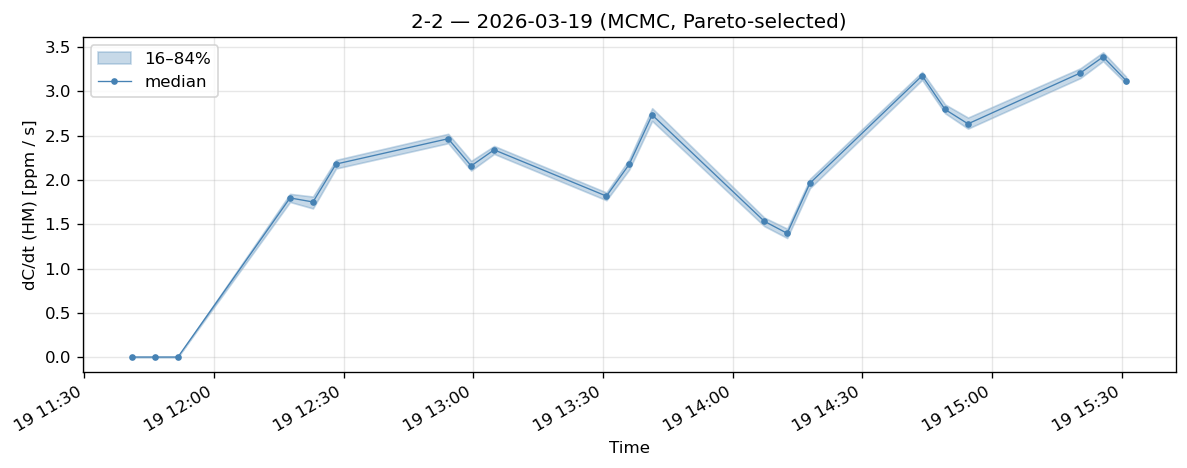

In [29]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
ax.fill_between(summary.index, summary['dcdt_q16'], summary['dcdt_q84'],
                color='steelblue', alpha=0.3, label='16–84%')
ax.plot(summary.index, summary['dcdt_median'], color='steelblue',
        marker='o', ms=3, lw=0.8, label='median')
ax.set_xlabel('Time')
ax.set_ylabel('dC/dt (HM) [ppm / s]')
ax.set_title(f'{chamber_id} — {data_folder.name} (MCMC, Pareto-selected)')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()